# Superoperator

Simulation of a quantum program involves encoding the state of the system and encoding operators that update the state according to the desired operation.

In *closed* quantum systems, we can encode our state in a *state vector* and our operations as *unitary matrices*. For a given bloq, we can query these objects with the `Bloq.tensor_contract()` method. Bloqs with only right registers correspond to states; and bloqs with thru registers correspond to unitary matrices. The tensor simulation protocol handles composing the states and unitaries to get e.g. the final state or unitary.

In *open* quantum systems, the state of our system is (potentially) a classically-probabalistic mixture over pure states (i.e. the states found in closed quantum systems). The operations map this mixture of states to a new mixture of states. The superoperator tensor protocol lets you simulate Qualtran programs that include non-unitary operations like measurement or discarding qubits. Any pure state can also be simulated using this protocol, but it is more expensive than the normal tensor simulation protocol; so we encourage that you use the ordinary tensor contraction protocol wherever feasible.


In [1]:
from qualtran.bloqs.basic_gates import PlusState, ZeroState, Hadamard, XGate, ZGate
from qualtran.bloqs.basic_gates.x_basis import MeasX
from qualtran.bloqs.basic_gates.z_basis import MeasZ
from qualtran.bloqs.basic_gates.discard import Discard, DiscardQ
from qualtran.bloqs.bookkeeping import Cast

from qualtran import BloqBuilder, CtrlSpec, QBit, CBit, Register, Side
from qualtran.drawing import show_bloq
from qualtran.simulation.tensor._quimb import cbloq_to_superquimb, cbloq_to_quimb

## Unitary measurement of an operator

Any Hermitian operator can be "measured" into a fresh ancilla using a simple prescription, see e.g. Nielsen and Chuang Exercise 4.44.

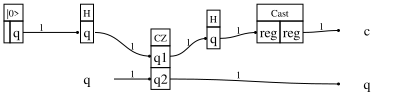

In [2]:
bb = BloqBuilder()
q = bb.add_register(Register("q", QBit()))
bb.add_register(Register("c", CBit(), side=Side.RIGHT))

op = ZGate()

meas_space = bb.add(ZeroState())
meas_space = bb.add(Hadamard(), q=meas_space)

_, add_ctrled = op.get_ctrl_system(CtrlSpec())
(meas_space,), (q,) = add_ctrled(bb, ctrl_soqs=[meas_space], in_soqs={'q': q})

meas_space = bb.add(Hadamard(), q=meas_space)
meas_result = bb.add(Cast(QBit(), CBit()), reg=meas_space)
#bb.add(DiscardQ(), x=q)
meas_cbloq = bb.finalize(c = meas_result, q=q)
show_bloq(meas_cbloq)

Note that we've entangled our system "q" with a fresh register. We've used a `Cast` operation to denote that the new bit is a classical bit. Practically this means we can no longer perform quantum operations like `Hadamard` to it, and any classical processing can happen on ordinary CPUs. But at a quantum-information level, there is nothing about the tensor structure to show that "c" is a 'classical' index. Below, we draw the tensor network encoding of the State/Unitary composite bloq using the ordinary tensor protocol

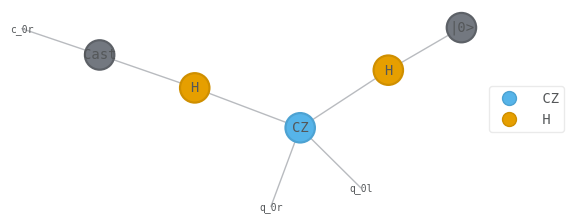

Tensor(shape=(2, 2, 2), inds=('q_0r', 'q_0l', 'c_0r'), tags=oset(['|0>', 'H', 'CZ', 'Cast']))

In [10]:
from qualtran.simulation.tensor import cbloq_to_quimb
tn = cbloq_to_quimb(meas_cbloq, friendly_indices=True)
tn.draw(color=['CZ', 'H'])
display(tn.contract())

## Open-system measurement of an operator

In an open system&mdash;like the world we live in&mdash;we don't have coherent access to each (qu)bit worth of information. Our measurement apparatus might have $10^{23}$ particles, each recording the result of a measurement. We can simulate the standard measurement channel where information is lost to the environment by using the previous circuit and discarding the coherent qubit wire. Now, the signature of our composite bloq takes in one `QBit()` and returns one `CBit()`.

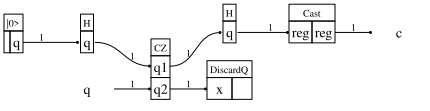

In [17]:
bb = BloqBuilder()
q = bb.add_register(Register("q", QBit(), side=Side.LEFT))
q, c = bb.add_from(meas_cbloq, q=q)
bb.add(DiscardQ(), x=q)
meas2_cbloq = bb.finalize(c=c)
show_bloq(meas2_cbloq)

The ordinary tensor simulation protocol is insufficient to handle discarding a qubit. 

In [19]:
try:
    tn = cbloq_to_quimb(meas2_cbloq, friendly_indices=True)
except ValueError as e:
    print("ValueError:", e)

ValueError: During tensor simulation, DiscardQ tried to discard information. This requires using TODO-open-system-sim-func


To remove a qubit, we need to sum over its possible states as we would when computing a marginal probability distribution. But our probability *amplitudes* only sum to 1 when we consider their absolute value squared
$$
\sum a^* a = 1,
$$
so our integration proceedure requires indexing into both our state $|\psi\rangle$ and its adjoint $\langle \psi|$ to remove the offending bit.

If you're using a densitry matrix, this correspond to performing a parital trace. In Qualtran, the superoperator tensor simulation protocol sets up two simultaneous tensor networks for simulating unitary action on the circuit *and* its adjoint. That is, we simulate both $|\psi\rangle$ and $\langle \psi|$.  Discarding a qubit is performed by contracting the qubit's index in the forward network with its corresponding index in the backwards, adjoint network.

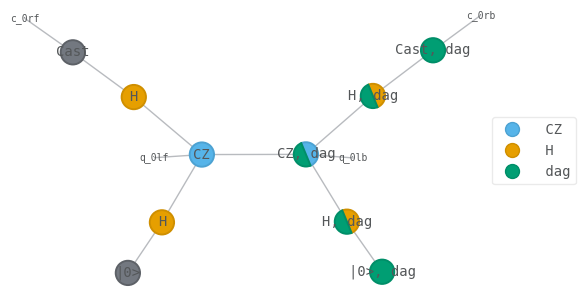

(2, 2, 2, 2)

In [21]:
tn = cbloq_to_superquimb(meas2_cbloq, friendly_indices=True)
tn.draw(color=['CZ', 'H', 'dag'], initial_layout='spectral')
display(tn.shape)

The discard operation couples the two pure evolutions. The superoperator is now a rank-4 tensor.

By the Stinespring dilation theorem, we can actually represent any superoperator (aka quantum channel, aka CPTP map) with only pure state evolution and the ability to discard qubits. This gives rise to the "System-Environment" representation of superoperators, which is the native representation in Qualtran. It is quite natural for the open-system operations we're most concerned with (like measurement); but practitioners may have to do some careful re-ordering of indices to encode superoperators traditionally expressed in another representation like the operator-sum (Kraus operator) representation.

## Implementation

The super-tensor protocol is a superset of the ordinary tensor simulation protocol. Bloqs override the same method to define their tensors for open-system simulation: the bloq author overrides `Bloq.my_tensors` and is responsible for returning a list of tensors whose indices follow the same prescribed format as documented in the [tensor protocol](.). 

All additional functionality is unlocked by the ability to return a `qualtran.simulation.tensor.DiscardInd` object in addition to `qtn.Tensor` objects. Per above, any superoperator can be expressed in this system-environment representation. This simple sentinel object flags the named index as subject to "tracing out" during construction of the complete network.

When calling `cbloq_to_quimb` the indices are faithfully kept as `(cxn: Connection, j: int)` tuples. During the conversion to the superoperator tensor network, each tensor returned by `Bloq.my_tensors` is added twice:
 - The 'forward' tensor is added. Its indices `(cxn, j)` are transformed to `(cxn, j, True)`
 - The 'backward' tensor is added. Its indices `(cxn, j)` are transformed to `(cxn, j, False)` and we take the element-wise complex conjugate of its data ndarray.
 - A `DiscardInd` will remove the booleans from the named index in tensors which have already been added. This causes the forward and backward indices to be contracted together.

Note that index permutation operations like taking the transpose of the backwards tensor is handled by the structure of the tensor network rather than messing with the data ndarray. 

The `my_tensors` override must order its return values such that a `DiscardInd` is encountered *after* the tensor that defines the index to discard. 

In [22]:
from qualtran.simulation.tensor import DiscardInd

ImportError: cannot import name 'DiscardInd' from 'qualtran.simulation.tensor' (/Users/mpharrigan/qutran/qutran/qualtran/simulation/tensor/__init__.py)

LeftDangle.q -> CNOT<2>.target 0 -- q_0l
CNOT<2>.target -> RightDangle.q 0 -- q_0r
Cast<4>.reg -> RightDangle.c 0 -- c_0r


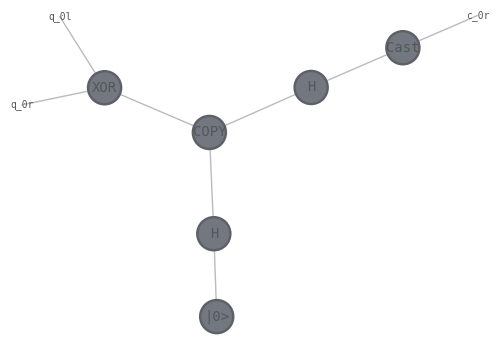

In [3]:
tn = cbloq_to_quimb(meas_cbloq)
from qualtran import LeftDangle, RightDangle


namemap = {}
for ind in tn.outer_inds():
    cxn, j = ind
    if cxn.left.binst is LeftDangle:
        soq = cxn.left
        side = 'l'
    if cxn.right.binst is RightDangle:
        soq = cxn.right
        side = 'r'

    idx = f'{soq.idx}' if soq.idx else ''
    namemap[ind] = f'{soq.reg.name}{idx}_{j}{side}'
    print(cxn, j, '--', namemap[ind])
tn2 = tn.reindex(namemap)
tn2.draw()
    

In [4]:
t = tn2.contract()
t

Tensor(shape=(2, 2, 2), inds=('q_0l', 'q_0r', 'c_0r'), tags=oset(['|0>', 'H', 'COPY', 'XOR', 'Cast']))

In [6]:
t.data

array([[[ 0.5+0.j,  0.5+0.j],
        [ 0.5+0.j, -0.5+0.j]],

       [[ 0.5+0.j, -0.5+0.j],
        [ 0.5+0.j,  0.5+0.j]]])

In [7]:
meas_cbloq.tensor_contract().round(4)

array([[ 0.5+0.j,  0.5+0.j],
       [ 0.5+0.j, -0.5+0.j],
       [ 0.5+0.j,  0.5+0.j],
       [-0.5+0.j,  0.5+0.j]])

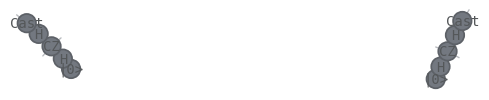

In [18]:
meas_tn = cbloq_to_superquimb(meas_cbloq)
meas_tn.draw(show_inds=False)

LeftDangle.q -> CZ<2>.q2 0 True -- q_0lf
LeftDangle.q -> CZ<2>.q2 0 False -- q_0lb
Cast<4>.reg -> RightDangle.c 0 True -- c_0rf
Cast<4>.reg -> RightDangle.c 0 False -- c_0rb


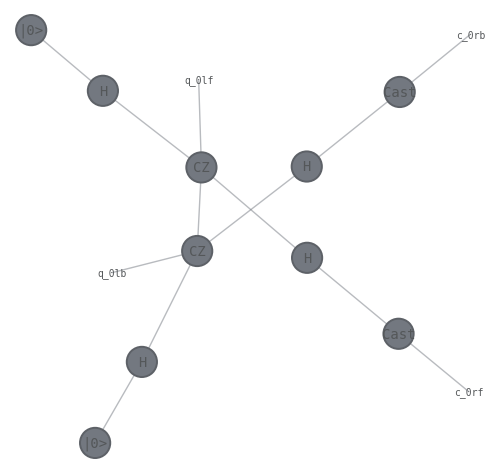

In [4]:
from qualtran import LeftDangle, RightDangle

tn = meas_tn

namemap = {}
for ind in tn.outer_inds():
    cxn, j, forward = ind
    if cxn.left.binst is LeftDangle:
        soq = cxn.left
        side = 'l'
    if cxn.right.binst is RightDangle:
        soq = cxn.right
        side = 'r'

    d = 'f' if forward else 'b'
    idx = f'{soq.idx}' if soq.idx else ''
    namemap[ind] = f'{soq.reg.name}{idx}_{j}{side}{d}'
    print(cxn, j, forward, '--', namemap[ind])
tn2 = tn.reindex(namemap)
tn2.draw()
    

In [7]:
import quimb.tensor as qtn
tnf, tnb = qtn.tensor_split(tn2.contract(), method='svd',
                            left_inds =['q_0lf', 'c_0rf'], 
                            absorb='both', bond_ind='j')
tnf

Tensor(shape=(2, 2, 2), inds=('q_0lf', 'c_0rf', 'j'), tags=oset(['|0>', 'H', 'CZ', 'Cast']))

In [11]:
tnf.data[:, :, 0].round(4)

array([[0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [15]:
tnb.data[:, :, 0].round(4)

array([[ 0.+0.j, -0.+0.j],
       [-1.+0.j, -0.+0.j]])

## Tests

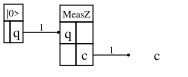

In [2]:
bb = BloqBuilder()
q = bb.add(ZeroState())
c = bb.add(MeasZ(), q=q)
cbloq = bb.finalize(c=c)
show_bloq(cbloq)

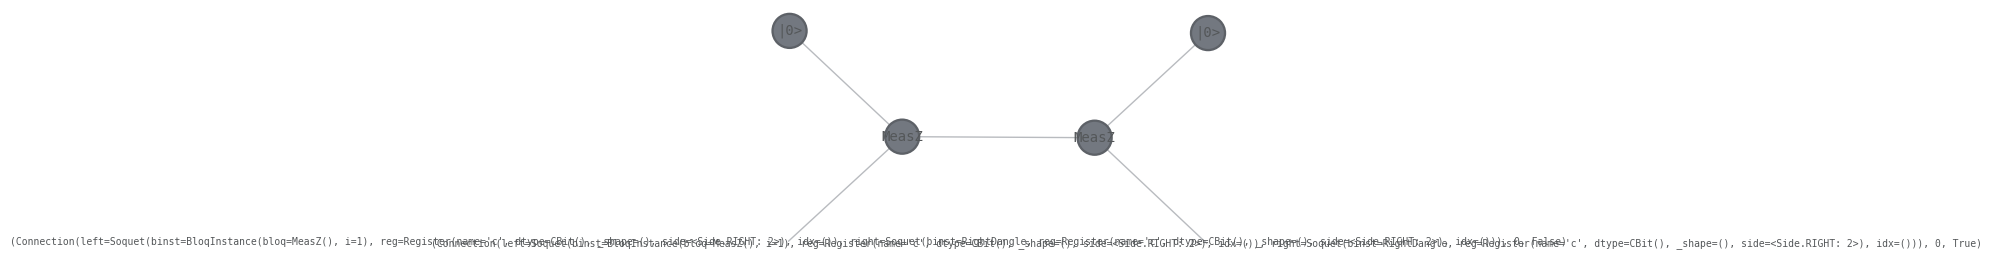

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

In [3]:
tn = cbloq_to_superquimb(cbloq)
tn.draw()
tn.contract().data

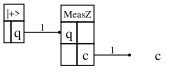

In [4]:
bb = BloqBuilder()
q = bb.add(PlusState())
c = bb.add(MeasZ(), q=q)
cbloq = bb.finalize(c=c)
show_bloq(cbloq)

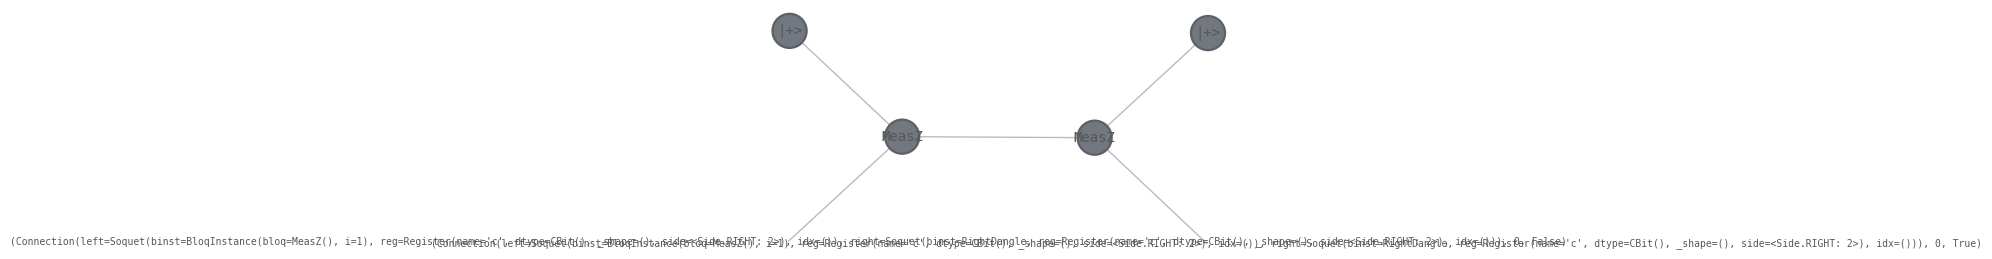

array([[0.5+0.j, 0. +0.j],
       [0. +0.j, 0.5+0.j]])

In [5]:
tn = cbloq_to_superquimb(cbloq)
tn.draw()
tn.contract().data

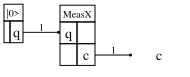

In [7]:
bb = BloqBuilder()
q = bb.add(ZeroState())
c = bb.add(MeasX(), q=q)
cbloq = bb.finalize(c=c)
show_bloq(cbloq)

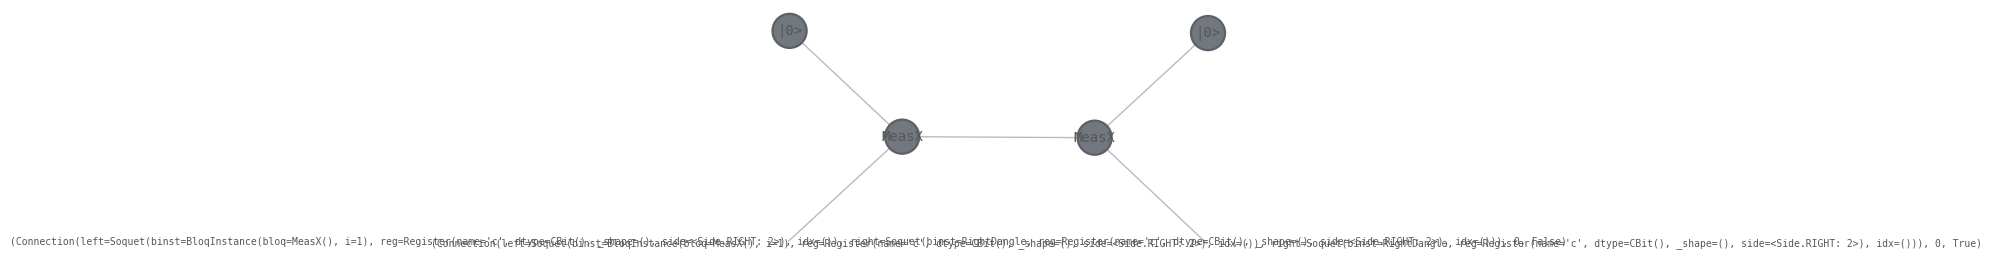

array([[0.5+0.j, 0. +0.j],
       [0. +0.j, 0.5+0.j]])

In [8]:
tn = cbloq_to_superquimb(cbloq)
tn.draw()
tn.contract().data